**Section 1 — Import Libraries**

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully")

Libraries Imported Successfully


**Section 2 — Load Dataset**

In [3]:
from google.colab import files

uploaded = files.upload()

Saving E Commerce Dataset.xlsx to E Commerce Dataset (1).xlsx


In [4]:
df = pd.read_excel("E Commerce Dataset.xlsx",
                   sheet_name="E Comm")

df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


**Section 3 — Dataset Overview**

In [5]:
print("="*50)
print("Dataset Shape")
print("="*50)

print(df.shape)

print()

print("="*50)
print("Column Names")
print("="*50)

print(df.columns)

Dataset Shape
(5630, 20)

Column Names
Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')


**Section 4 — Basic Information**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

**Section 5 — Statistical Summary**

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.50,54222.7500,55630.00
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.00,0.0000,1.00
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.00,16.0000,61.00
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.00,3.0000,3.00
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.0000,5.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.00,1.0000,1.00


**Section 6 — Check Missing Values**

In [8]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
DaySinceLastOrder,307
OrderAmountHikeFromlastYear,265
Tenure,264
OrderCount,258
CouponUsed,256
HourSpendOnApp,255
WarehouseToHome,251


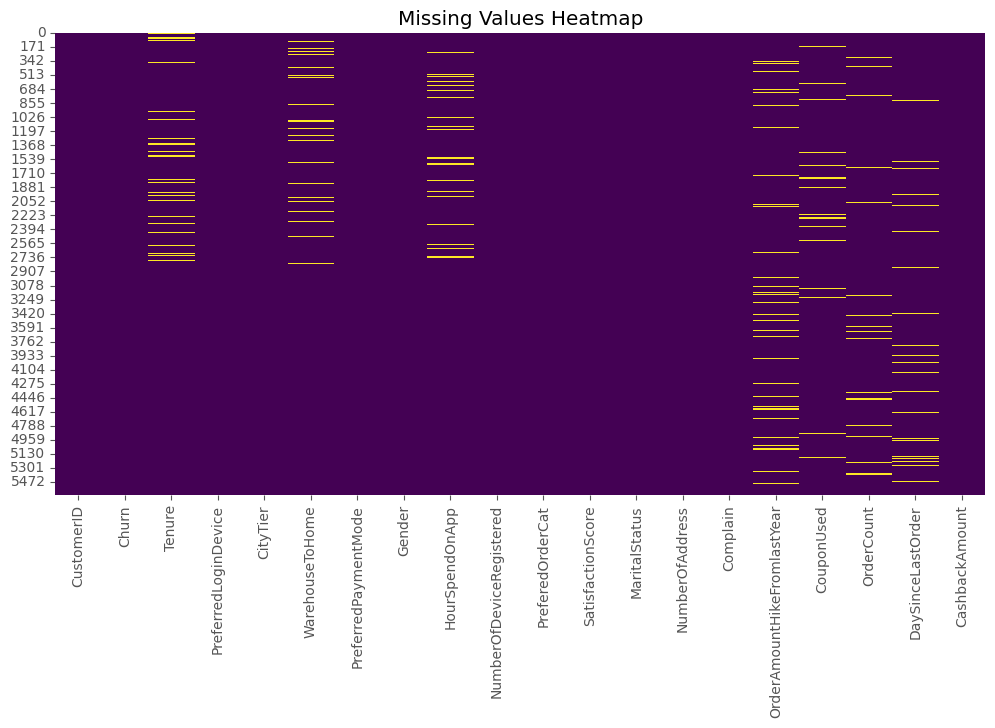

In [23]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

**Section 7 — Duplicate Values**

In [10]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


**Section 8 — Check Data Types**

In [11]:
df.dtypes

,0
CustomerID,int64
Churn,int64
Tenure,float64
PreferredLoginDevice,object
CityTier,int64
WarehouseToHome,float64
PreferredPaymentMode,object
Gender,object
HourSpendOnApp,float64
NumberOfDeviceRegistered,int64


**Section 9 — Target Variable Analysis**

In [13]:
df["Churn"].value_counts()

,count
Churn,
0,4682
1,948


Visualization

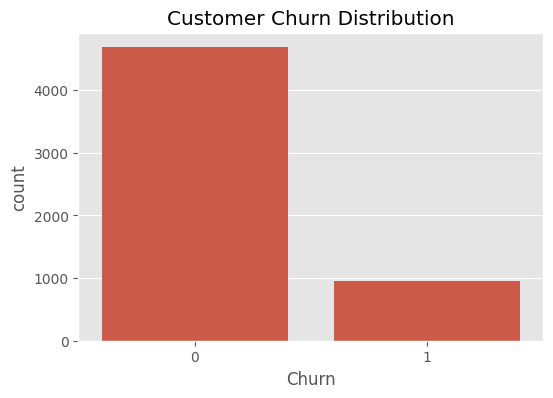

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Churn")

plt.title("Customer Churn Distribution")

plt.show()

**Section 10 — Correlation Heatmap**

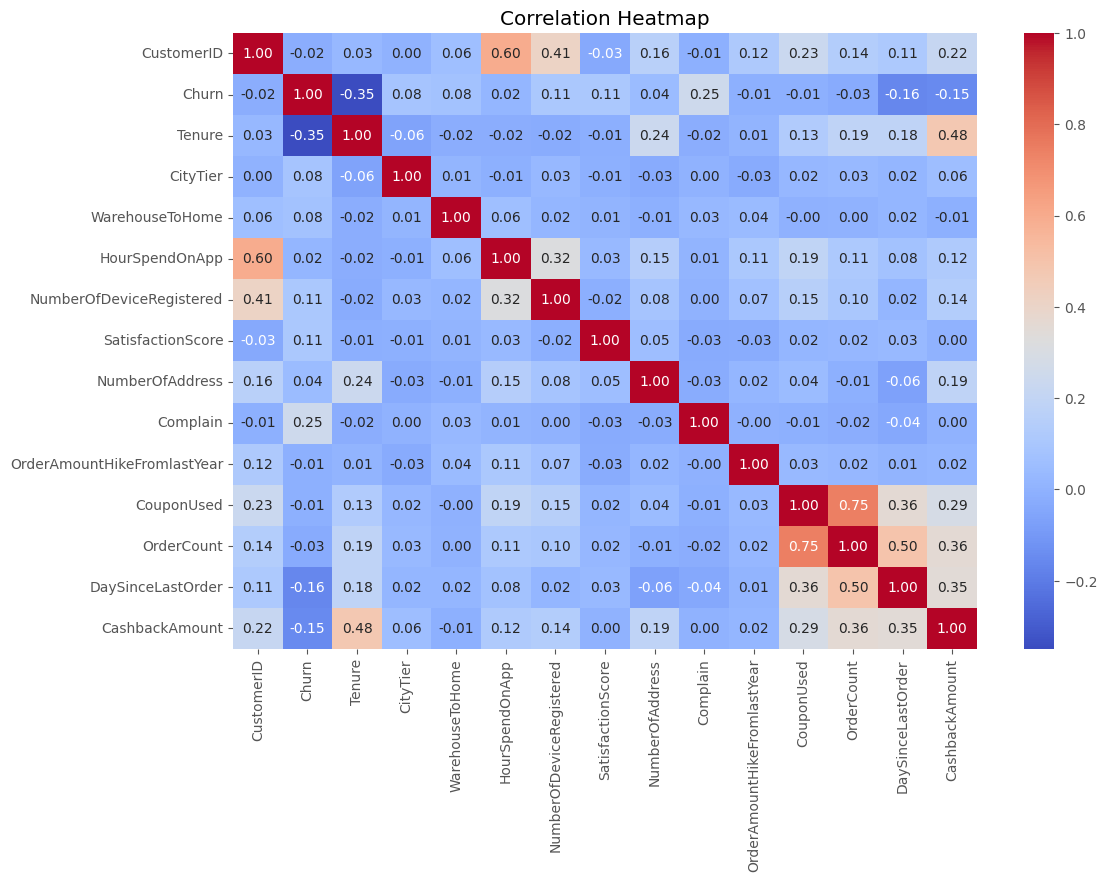

In [19]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

**Section 11 — Churn vs Features**

Churn vs Tenure

<Axes: xlabel='Churn', ylabel='Tenure'>

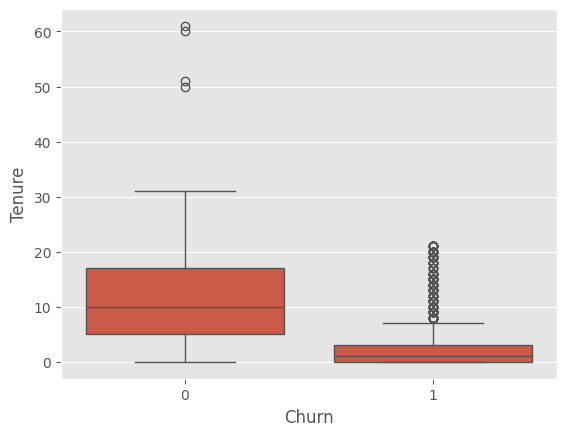

In [25]:
sns.boxplot(data=df,
            x="Churn",
            y="Tenure")

Churn vs Satisfaction Score


<Axes: xlabel='Churn', ylabel='SatisfactionScore'>

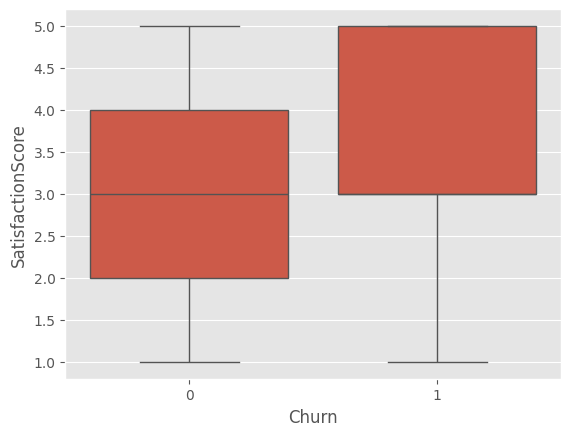

In [26]:
sns.boxplot(data=df,
            x="Churn",
            y="SatisfactionScore")

Churn vs Days Since Last Order

<Axes: xlabel='Churn', ylabel='DaySinceLastOrder'>

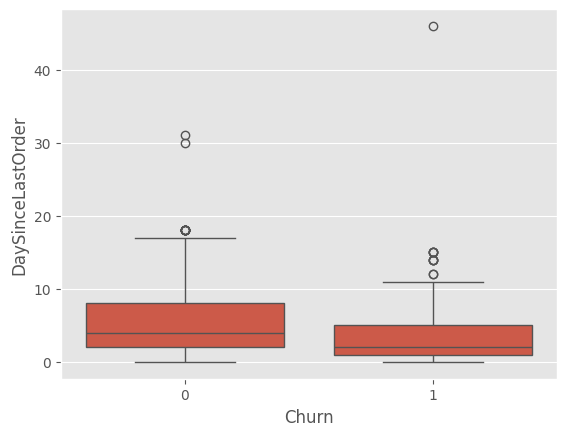

In [27]:
sns.boxplot(data=df,
            x="Churn",
            y="DaySinceLastOrder")

 Churn vs Complaint

<Axes: xlabel='Complain', ylabel='count'>

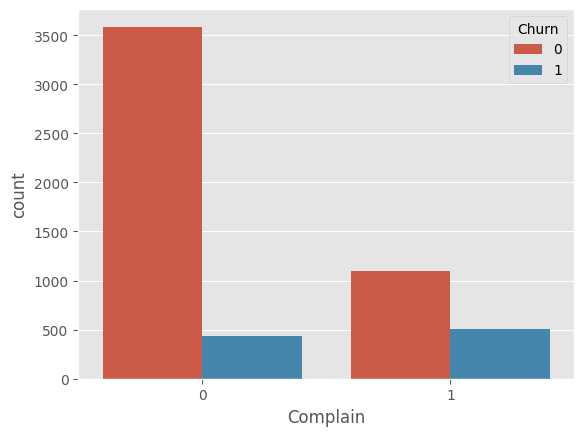

In [28]:
sns.countplot(data=df,
              x="Complain",
              hue="Churn")

Churn vs Payment Mode

<Axes: xlabel='PreferredPaymentMode', ylabel='count'>

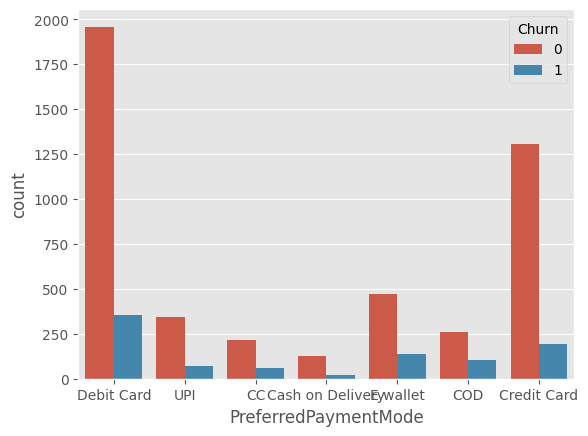

In [29]:
sns.countplot(data=df,
              x="PreferredPaymentMode",
              hue="Churn")

Rotate labels

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

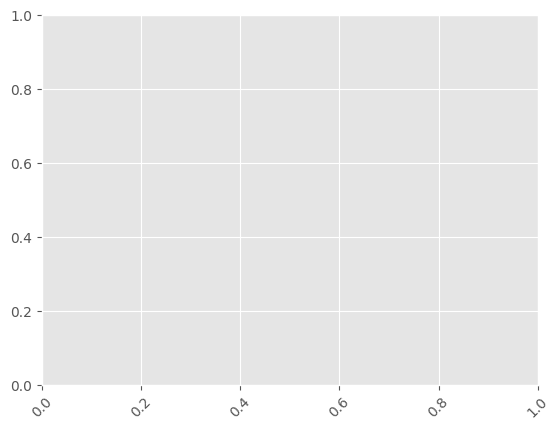

In [30]:
plt.xticks(rotation=45)

Churn vs Preferred Order Category

<Axes: xlabel='PreferedOrderCat', ylabel='count'>

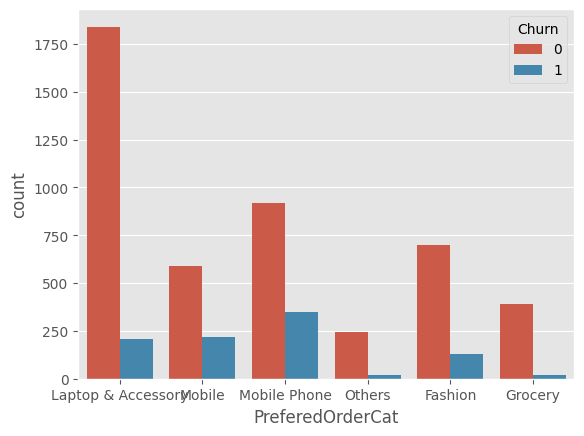

In [31]:
sns.countplot(data=df,
              x="PreferedOrderCat",
              hue="Churn")

Rotate labels

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

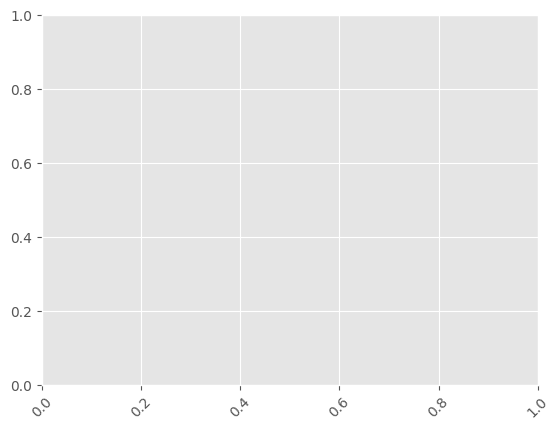

In [32]:
plt.xticks(rotation=45)

**Section 12 — Business Insights**

## Business Insights

- Customers with shorter tenure appear more likely to churn.
- Customers who submitted complaints have a higher churn rate.
- Lower satisfaction scores are associated with increased churn.
- Longer periods since the last order correlate with higher churn.
- Customers with fewer orders show a greater tendency to leave.